In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import importlib
import sys
import os
sns.set_theme(style="whitegrid", context="talk")
from energy_option_pricer_forward_hedge import ElectricitySpotAsianPricer
sys.path.append(os.path.abspath(".."))
%load_ext autoreload
%autoreload 2
    
from dask.distributed import Client
#client = Client("tcp://131.169.114.219:8786")
client = Client("tcp://192.168.178.33:8786")

## Model Overview

The model used for option pricing is based on Merton's jump-diffusion:

$$
dF_t = \kappa(\theta(t) - F_t)\,dt + \sigma_t F_t\, dW_t + JdN_t
$$

with stochastic volatility:

$$
d\sigma_t = a(b - \sigma_t)\,dt + \eta\, dZ_t
$$

and correlated Brownian motions:

$$
\mathrm{corr}(W_t, Z_t) = \rho
$$

Jumps are modeled with a Poisson arrival process, and jump size is sampled from an empirical positive-jump distribution:

$$
dN_t \sim Poisson(\lambda dt), J \sim Norm(\mu_j, \sigma_j^2)
$$

The option payoff is modeled as:

$$
\max\left(\frac{1}{N}\sum_{i=1}^{N} S_{t_i} - K, 0\right)
$$

as for an **Asian-style contract on average spot**, specifically for delivery-window products in power markets.

In [2]:
pricer = ElectricitySpotAsianPricer(seed=42)


# Load data
hourly = pricer.load_hourly_csv(
    "germany_hourly_prices.csv",
    country_iso="DEU",
    timezone_col_priority=("Datetime (Local)", "Datetime (UTC)")
)

daily = pricer.aggregate_hourly_to_daily()
print(daily.head())

# Calibrate
cal = pricer.calibrate(regime="all", use_hourly=True, verbose=10)
print(pd.DataFrame([cal.__dict__]))

# Price the option
K = 80.0
T = 0.50

price_out = pricer.price_asian_call_cv_mc(
    K=K,
    T=T,
    regime="all",
    use_hourly=True,
    n_paths=12000,
    n_steps=365,
    antithetic=True,
    n_jobs=-1,
    verbose=10,
    sampling="mc",
    control_variate="average",
)
print(pd.DataFrame([price_out]))

# Greeks
greeks = pricer.finite_difference_greeks(
    K=K,
    T=T,
    regime="all",
    use_hourly=True,
    n_paths=4000,
    n_steps=365,
    antithetic=True,
    n_jobs=5,
    mc_n_jobs=1,
    verbose=10,
)
print(pd.DataFrame([greeks]))

                Price
Date                 
2015-01-01  22.340000
2015-01-02  22.340000
2015-01-03  22.340000
2015-01-04  22.340000
2015-01-05  35.857083
[CAL] started | regime=all
[CAL] finished | kappa=20.3342 | sigma0=397.7461 | z_cut=4.793 | jump_count=1167
  regime  theta_mean      kappa    sigma0   sigma_bar         a       eta  \
0    all   73.398104  20.334246  397.7461  582.034515  0.764461  0.514553   

        rho  jump_lambda    jump_mu  ...  jump_threshold_z  jump_count  \
0 -0.019876    56.181936  55.072955  ...          4.793262        1167   

   obs_frequency_years  obs_per_day  obs_per_year  spot_bump_scale  \
0             0.000114         24.0        8766.0             3.52   

   sigma_bump_scale    jump_cap  sigma_floor  sigma_ceiling  
0         19.887305  236.553319    303.69494    4022.972746  

[1 rows x 25 columns]
[PRICE-CV] started | regime=all | T=0.5 | paths=12000 | steps=365 | sampling=mc | jobs=12
[PRICE-CV] Monte Carlo / Sobol engine running


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


[PRICE-CV] finished | price=18.148570 | stderr=0.085256 | beta=0.7184
      price    stderr  discount_factor      beta  cv_expect sampling  \
0  18.14857  0.085256              1.0  0.718408   81.99895       mc   

  control_variate  n_paths  
0         average    24000  
[GREEKS] started | regime=all | T=0.5 | jobs=5
[GREEKS] pricing base / bumps


[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    3.9s
[Parallel(n_jobs=12)]: Done   3 out of  12 | elapsed:    4.0s remaining:   12.0s
[Parallel(n_jobs=12)]: Done   5 out of  12 | elapsed:    4.1s remaining:    5.7s
[Parallel(n_jobs=12)]: Done   7 out of  12 | elapsed:    4.1s remaining:    2.9s
[Parallel(n_jobs=12)]: Done   9 out of  12 | elapsed:    4.1s remaining:    1.4s
[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:    4.1s finished
[Parallel(n_jobs=5)]: Using backend ThreadingBackend with 5 concurrent workers.


[GREEKS] finished | price=17.765656 | delta=0.052475 | vega=0.014541
       price     delta      vega    dS         dV
0  17.765656  0.052475  0.014541  3.52  19.887305


[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:    1.0s remaining:    1.4s
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:    1.0s remaining:    0.7s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:    1.1s finished


In [8]:
stress = pricer.stress_test_table(
    K=80.0, T=0.50, regime="all", use_hourly=True,
    n_paths=12000, n_steps=365, antithetic=True,
    seed=42, n_jobs=1, verbose=10,
)

print(stress)

    SpotShockPct  VolScale  ShockedSpot  ShockedSigma0      Price    StdErr  \
0          -0.50       0.5        46.62      198.87305  14.905507  0.085062   
1          -0.50       1.0        46.62      397.74610  15.863796  0.088214   
2          -0.50       1.5        46.62      596.61915  19.009859  0.104086   
3          -0.50       2.0        46.62      795.49220  22.156896  0.120712   
4          -0.25       0.5        69.93      198.87305  16.117844  0.082780   
5          -0.25       1.0        69.93      397.74610  16.861145  0.088202   
6          -0.25       1.5        69.93      596.61915  20.249468  0.103184   
7          -0.25       2.0        69.93      795.49220  23.557163  0.120311   
8           0.00       0.5        93.24      198.87305  17.116012  0.080175   
9           0.00       1.0        93.24      397.74610  18.181228  0.086801   
10          0.00       1.5        93.24      596.61915  20.954330  0.100141   
11          0.00       2.0        93.24      795.492

In [3]:
pricer.load_hourly_csv("germany_hourly_prices.csv", country_iso="DEU")
pricer.load_futures_csv("german_futures_prices.csv", dayfirst=None)

proxy = pricer.fit_forward_proxy(use_hourly=True, verbose=10)
print(proxy)

hedge = pricer.simulate_dynamic_forward_hedge(
    K=80.0,
    T=0.5,
    regime="all",
    use_hourly=True,
    n_outer_paths=48,
    n_inner_paths=256,
    #n_steps = 26,
    n_jobs=1,
    verbose=10,
)

print(pricer.hedge_pnl_table(hedge))

[FWD] fitted proxy | alpha=73.752010 | beta=0.240668 | r2=0.2517 | n=1962 | n_weekly=401
{'alpha': 73.75201049458471, 'beta': 0.24066827120012677, 'r2': 0.25169922107527554, 'n_obs': 1962, 'n_weekly': 401, 'start': Timestamp('2017-06-27 00:00:00'), 'end': Timestamp('2025-03-06 00:00:00'), 'spot_mean': 93.78376868841319, 'forward_mean': 96.3227879714577, 'spot_std': 90.5546440162203, 'forward_std': 83.72729138224855}
[HEDGE] instrument=synthetic_forward (model-implied, delivery-matched)
[HEDGE] started | outer=48 | inner=256 | rebals=28 | jobs=1
[HEDGE] Step 1/4: simulating outer paths
[HEDGE] Step 3/4: dynamic rebalancing
[HEDGE] Step 4/4: summarizing hedge PnL
[HEDGE] finished | mean_pnl=-69.893441 | var99=-546.630017
        Mean         Std         Min          1%          5%        25%  \
0 -69.893441  124.985511 -636.780083 -546.630017 -245.442886 -76.604839   

      Median        75%        95%         99%         Max       VaR99  \
0 -61.018945 -15.086687  29.788223  163.653713

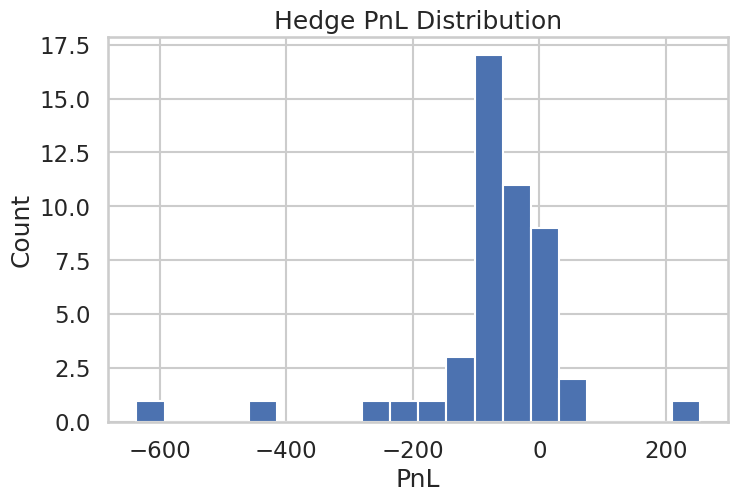

In [4]:
pnl = pd.Series(hedge["pnl_paths"])

plt.figure(figsize=(8, 5))
plt.hist(pnl, bins=20)
plt.title("Hedge PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Count")
plt.show()

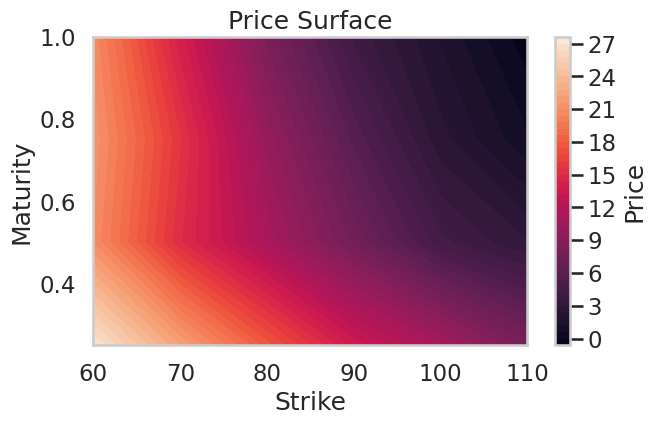

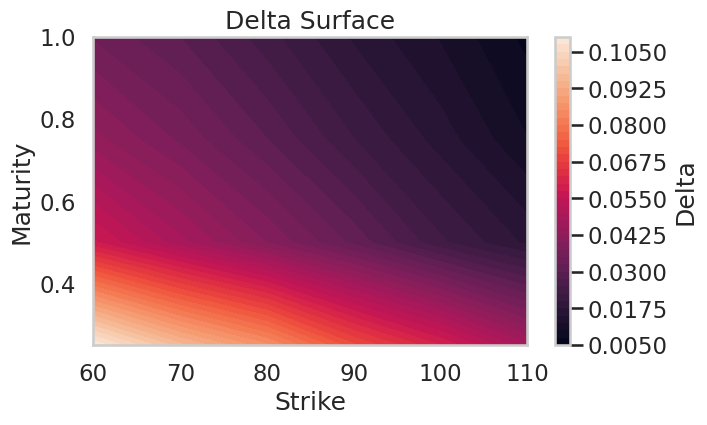

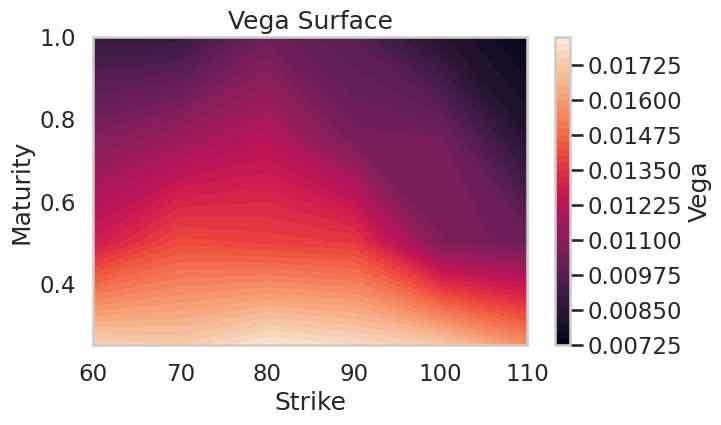

In [5]:
surface = pricer.build_greek_surface(
    strikes=[60, 70, 80, 90, 100, 110],
    maturities=[0.25, 0.50, 0.75, 1.00],
    regime="all",
    use_hourly=True,
    n_paths=2500,
    n_jobs=1,
    verbose=0,
)

pivot_price = surface.pivot(index="maturity", columns="strike", values="price")
pivot_delta = surface.pivot(index="maturity", columns="strike", values="delta")
pivot_vega  = surface.pivot(index="maturity", columns="strike", values="vega")

for title, grid, label in [
    ("Price Surface", pivot_price, "Price"),
    ("Delta Surface", pivot_delta, "Delta"),
    ("Vega Surface", pivot_vega, "Vega"),
]:
    plt.figure(figsize=(7,4))
    plt.contourf(grid.columns, grid.index, grid.values, levels=50)
    plt.colorbar(label=label)
    plt.title(title)
    plt.xlabel("Strike")
    plt.ylabel("Maturity")
    plt.show()